# Análisis de Rendimiento: Proyecto Alpha TCP
Este notebook analiza los resultados de las pruebas de estrés de nuestro servidor TCP Thread

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos las cantidades de clientes que probamos en las pruebas
clientes = [50, 100, 150, 200]

# 2. Creamos listas vacías para ir guardando los resultados de cada prueba
promedios_login = []
desviacion_login = []
promedios_hit = []
desviacion_hit = []
porcentaje_exito = []

# Esta lista nos dirá de cuáles archivos SÍ encontramos datos
clientes_graficables = [] 

## 1. Procesamiento de Datos
A continuación, abriremos cada archivo CSV uno por uno usando un ciclo. 
Para cada archivo que encuentre, el programa hará lo siguiente:
1. Convertirá el tiempo de nanosegundos a milisegundos (para que sea legible).
2. Separará los datos de la operación `LOGIN` y la operación `HIT`.
3. Calculará los promedios y el porcentaje de éxito con matemáticas básicas.

In [13]:
for num_clientes in clientes:
    # Armamos el nombre exacto del archivo que queremos buscar
    archivo_prueba = f"resultados_estresamiento_{num_clientes}_clientes.csv"
    
    # Intentamos leer el archivo (si no existe, fallará aquí antes de guardar nada)
    df = pd.read_csv(archivo_prueba)
    
    # Convertimos nanosegundos a milisegundos dividiendo entre 1 millón
    df['TiempoMS'] = df['TiempoRespuesta (Nano Sec)'] / 1000000.0
    
    # Filtramos los datos en dos tablas separadas
    df_login = df[df['TipoOperacion'] == 'LOGIN']
    df_hit = df[df['TipoOperacion'] == 'HIT']
    
    # Calculamos promedios y desviación estándar
    prom_login = df_login['TiempoMS'].mean()
    desv_login = df_login['TiempoMS'].std()
    
    prom_hit = df_hit['TiempoMS'].mean()
    desv_hit = df_hit['TiempoMS'].std()
    
    # Calculamos el porcentaje de éxito (logins exitosos / total de logins) * 100
    total_logins = len(df_login)
    logins_exitosos = len(df_login[df_login['Exitoso'] == True])
    
    if total_logins > 0:
        porcentaje = (logins_exitosos / total_logins) * 100
    else:
        porcentaje = 0
        
    promedios_login.append(prom_login)
    desviacion_login.append(desv_login)
    promedios_hit.append(prom_hit)
    desviacion_hit.append(desv_hit)
    porcentaje_exito.append(porcentaje)
    clientes_graficables.append(num_clientes)

In [ ]:
df_resultados = pd.DataFrame({
    'Clientes Concurrentes': clientes_graficables,
    'Promedio Registro (ms)': promedios_login,
    'Desv_Est Registro (ms)': desviacion_login,
    'Promedio Juego (ms)': promedios_hit,
    'Desv_Est Juego (ms)': desviacion_hit,
    'Exito Registro (%)': porcentaje_exito
})

# Mostramos la tabla(redondeando a 2 decimales)
display(df_resultados.round(2))

,Clientes Concurrentes,Promedio Registro (ms),Desv_Est Registro (ms),Promedio Juego (ms),Desv_Est Juego (ms),Exito Registro (%)
0,50,3.05,3.03,1.16,5.56,100.00
1,100,3.73,5.71,1.88,8.75,99.60
2,150,5.78,5.59,2.13,5.45,95.13
3,200,6.59,6.28,2.47,7.18,89.00


## 2. Visualización de Resultados
Finalmente, tomamos las listas que llenamos en el paso anterior y usamos `matplotlib` para generar nuestras dos gráficas principales

In [15]:
x = df_resultados['Clientes Concurrentes']
y_login = df_resultados['Promedio Registro (ms)']
std_login = df_resultados['Desv_Est Registro (ms)']
y_hit = df_resultados['Promedio Juego (ms)']
std_hit = df_resultados['Desv_Est Juego (ms)']

## Gráfica 1: Tiempo Pormedio 

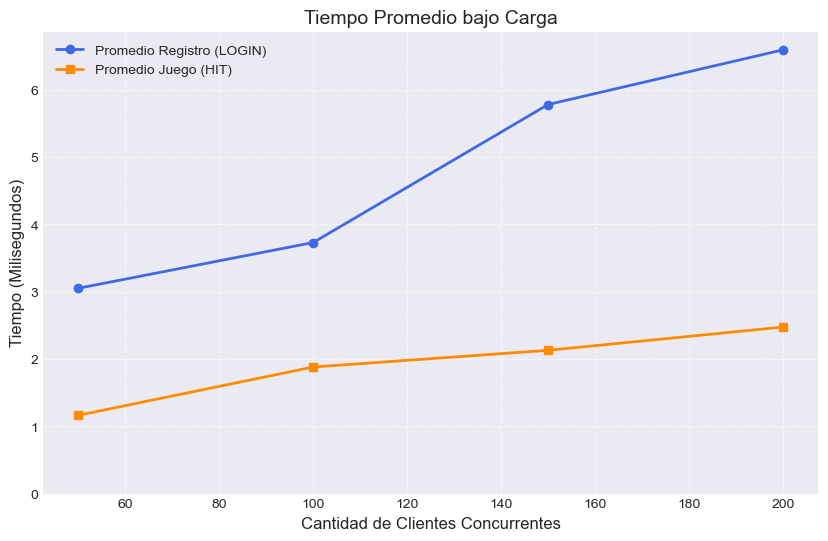

In [20]:
plt.figure(figsize=(10, 6))

# Línea y sombra (desviación) para el Registro (LOGIN)
plt.plot(x, y_login, marker='o', color='royalblue', label='Promedio Registro (LOGIN)', linewidth=2)

# Línea y sombra (desviación) para el Juego (HIT)
plt.plot(x, y_hit, marker='s', color='darkorange', label='Promedio Juego (HIT)', linewidth=2)

# Añadimos títulos y etiquetas
plt.title('Tiempo Promedio bajo Carga', fontsize=14)
plt.xlabel('Cantidad de Clientes Concurrentes', fontsize=12)
plt.ylabel('Tiempo (Milisegundos)', fontsize=12)
plt.ylim(bottom=0) # Forzamos que el eje Y no baje de cero
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos la gráfica
plt.show()

## Gráfica 2: Desviación Estandar

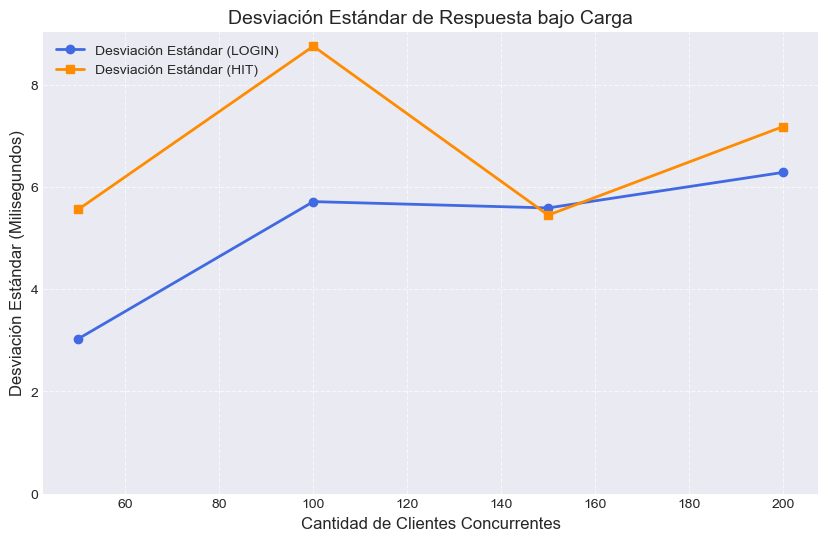

In [19]:
plt.figure(figsize=(10, 6))

# Línea de la Desviación Estándar para el Registro (LOGIN)
plt.plot(x, std_login, marker='o', color='royalblue', label='Desviación Estándar (LOGIN)', linewidth=2)

# Línea de la Desviación Estándar para el Juego (HIT)
plt.plot(x, std_hit, marker='s', color='darkorange', label='Desviación Estándar (HIT)', linewidth=2)

# Añadimos títulos y etiquetas actualizados
plt.title('Desviación Estándar de Respuesta bajo Carga', fontsize=14)
plt.xlabel('Cantidad de Clientes Concurrentes', fontsize=12)
plt.ylabel('Desviación Estándar (Milisegundos)', fontsize=12)
plt.ylim(bottom=0) # Forzamos que el eje Y no baje de cero
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos la gráfica
plt.show()

## Gráfica 3: Porciento de Éxitos 

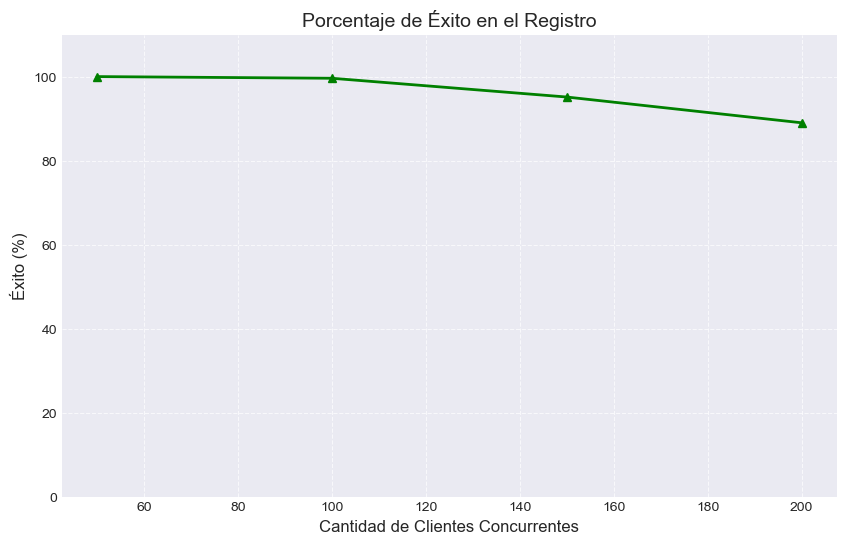

In [ ]:
plt.figure(figsize=(10, 6))

# Extraemos los datos directamente de la tabla (df_resultados)
x = df_resultados['Clientes Concurrentes']
y_exito = df_resultados['Exito Registro (%)']

plt.plot(x, y_exito, marker='^', color='green', linewidth=2)

# Añadimos títulos y etiquetas
plt.title('Porcentaje de Éxito en el Registro', fontsize=14)
plt.xlabel('Cantidad de Clientes Concurrentes', fontsize=12)
plt.ylabel('Éxito (%)', fontsize=12)
plt.ylim(0, 110) # Forzamos que el eje Y vaya de 0 a 100% (con margen a 110 para que se vea bien)
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos la gráfica
plt.show()